<a href="https://colab.research.google.com/github/dneguja/neguja.cse-davprojects/blob/main/Human_Gait_Recognition_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   step_length  stride_width  walking_speed  body_angle  person_id
0           50            20            3.0          10          0
1           55            21            3.2          11          0
2           60            22            3.5          12          0
3           62            23            3.8          13          0
4           65            24            4.0          14          1
5           70            25            4.2          15          1
6           72            26            4.5          16          1
7           75            27            4.8          17          1
8           80            28            5.0          18          2
9           85            29            5.2          19          2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   step_length    10 non-null     int64  
 1   stride_width   10 non-nul

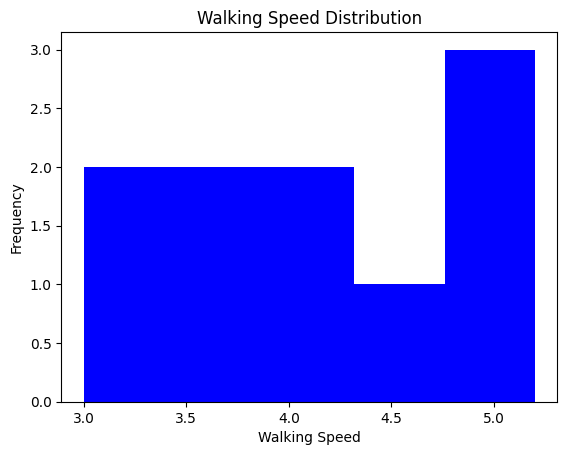

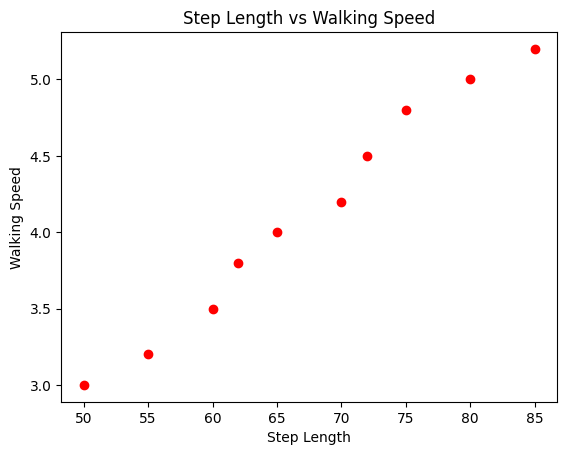

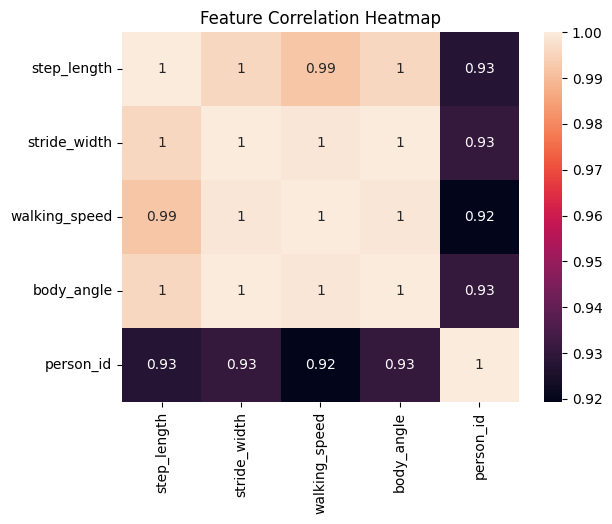

Accuracy: 0.6666666666666666
Accuracy: 0.6666666666666666


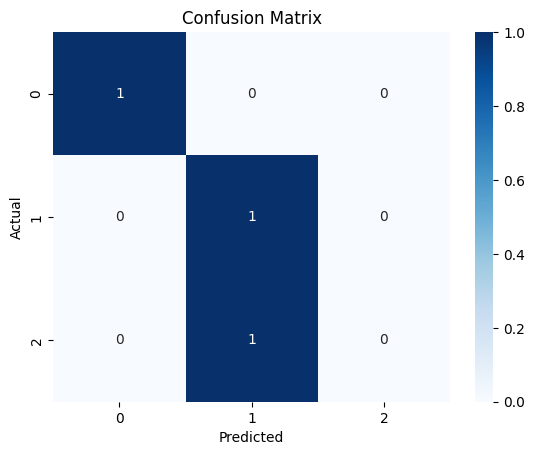

Predicted Person ID: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Sample gait dataset

data = {
    'step_length': [50,55,60,62,65,70,72,75,80,85],
    'stride_width': [20,21,22,23,24,25,26,27,28,29],
    'walking_speed': [3,3.2,3.5,3.8,4,4.2,4.5,4.8,5,5.2],
    'body_angle': [10,11,12,13,14,15,16,17,18,19],
    'person_id': [0,0,0,0,1,1,1,1,2,2]
}
df = pd.DataFrame(data)

print(df)
# Dataset information

print(df.info())

# Statistical summary

print(df.describe())
plt.hist(df['walking_speed'], bins=5, color='blue')

plt.title("Walking Speed Distribution")
plt.xlabel("Walking Speed")
plt.ylabel("Frequency")

plt.show()
plt.scatter(df['step_length'], df['walking_speed'], color='red')

plt.title("Step Length vs Walking Speed")
plt.xlabel("Step Length")
plt.ylabel("Walking Speed")

plt.show()
sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()
# Features and target

X = df[['step_length', 'stride_width', 'walking_speed', 'body_angle']]
y = df['person_id']

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Create model

model = RandomForestClassifier()

# Train model

model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
# New gait sample

new_person = [[68, 24, 4.1, 14]]

prediction = model.predict(new_person)

print("Predicted Person ID:", prediction[0])
